In [ ]:
import base64
import os
from pathlib import Path

import requests
from dotenv import load_dotenv

In [ ]:
load_dotenv()
OPENROUTER_API_KEY=os.environ["OPENROUTER_API_KEY"]

True

In [12]:
def generate_image(
    prompt: str,
    output_path: str = "draft/generated.png",
    model: str = "bytedance-seed/seedream-4.5",
) -> Path:
    """
    Generate Image liveraging Openrouter
    """
    response = requests.post(
        "https://openrouter.ai/api/v1/images",
        headers={
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
            "Content-Type": "application/json",
        },
        json={
            "model": model,
            "prompt": prompt,
        },
        timeout = 360
    )

    response.raise_for_status()

    result = response.json()

    image_base64 = result["data"][0]["b64_json"]

    image_bytes = base64.b64decode(image_base64)

    path = Path(output_path)

    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(image_bytes)

    return path

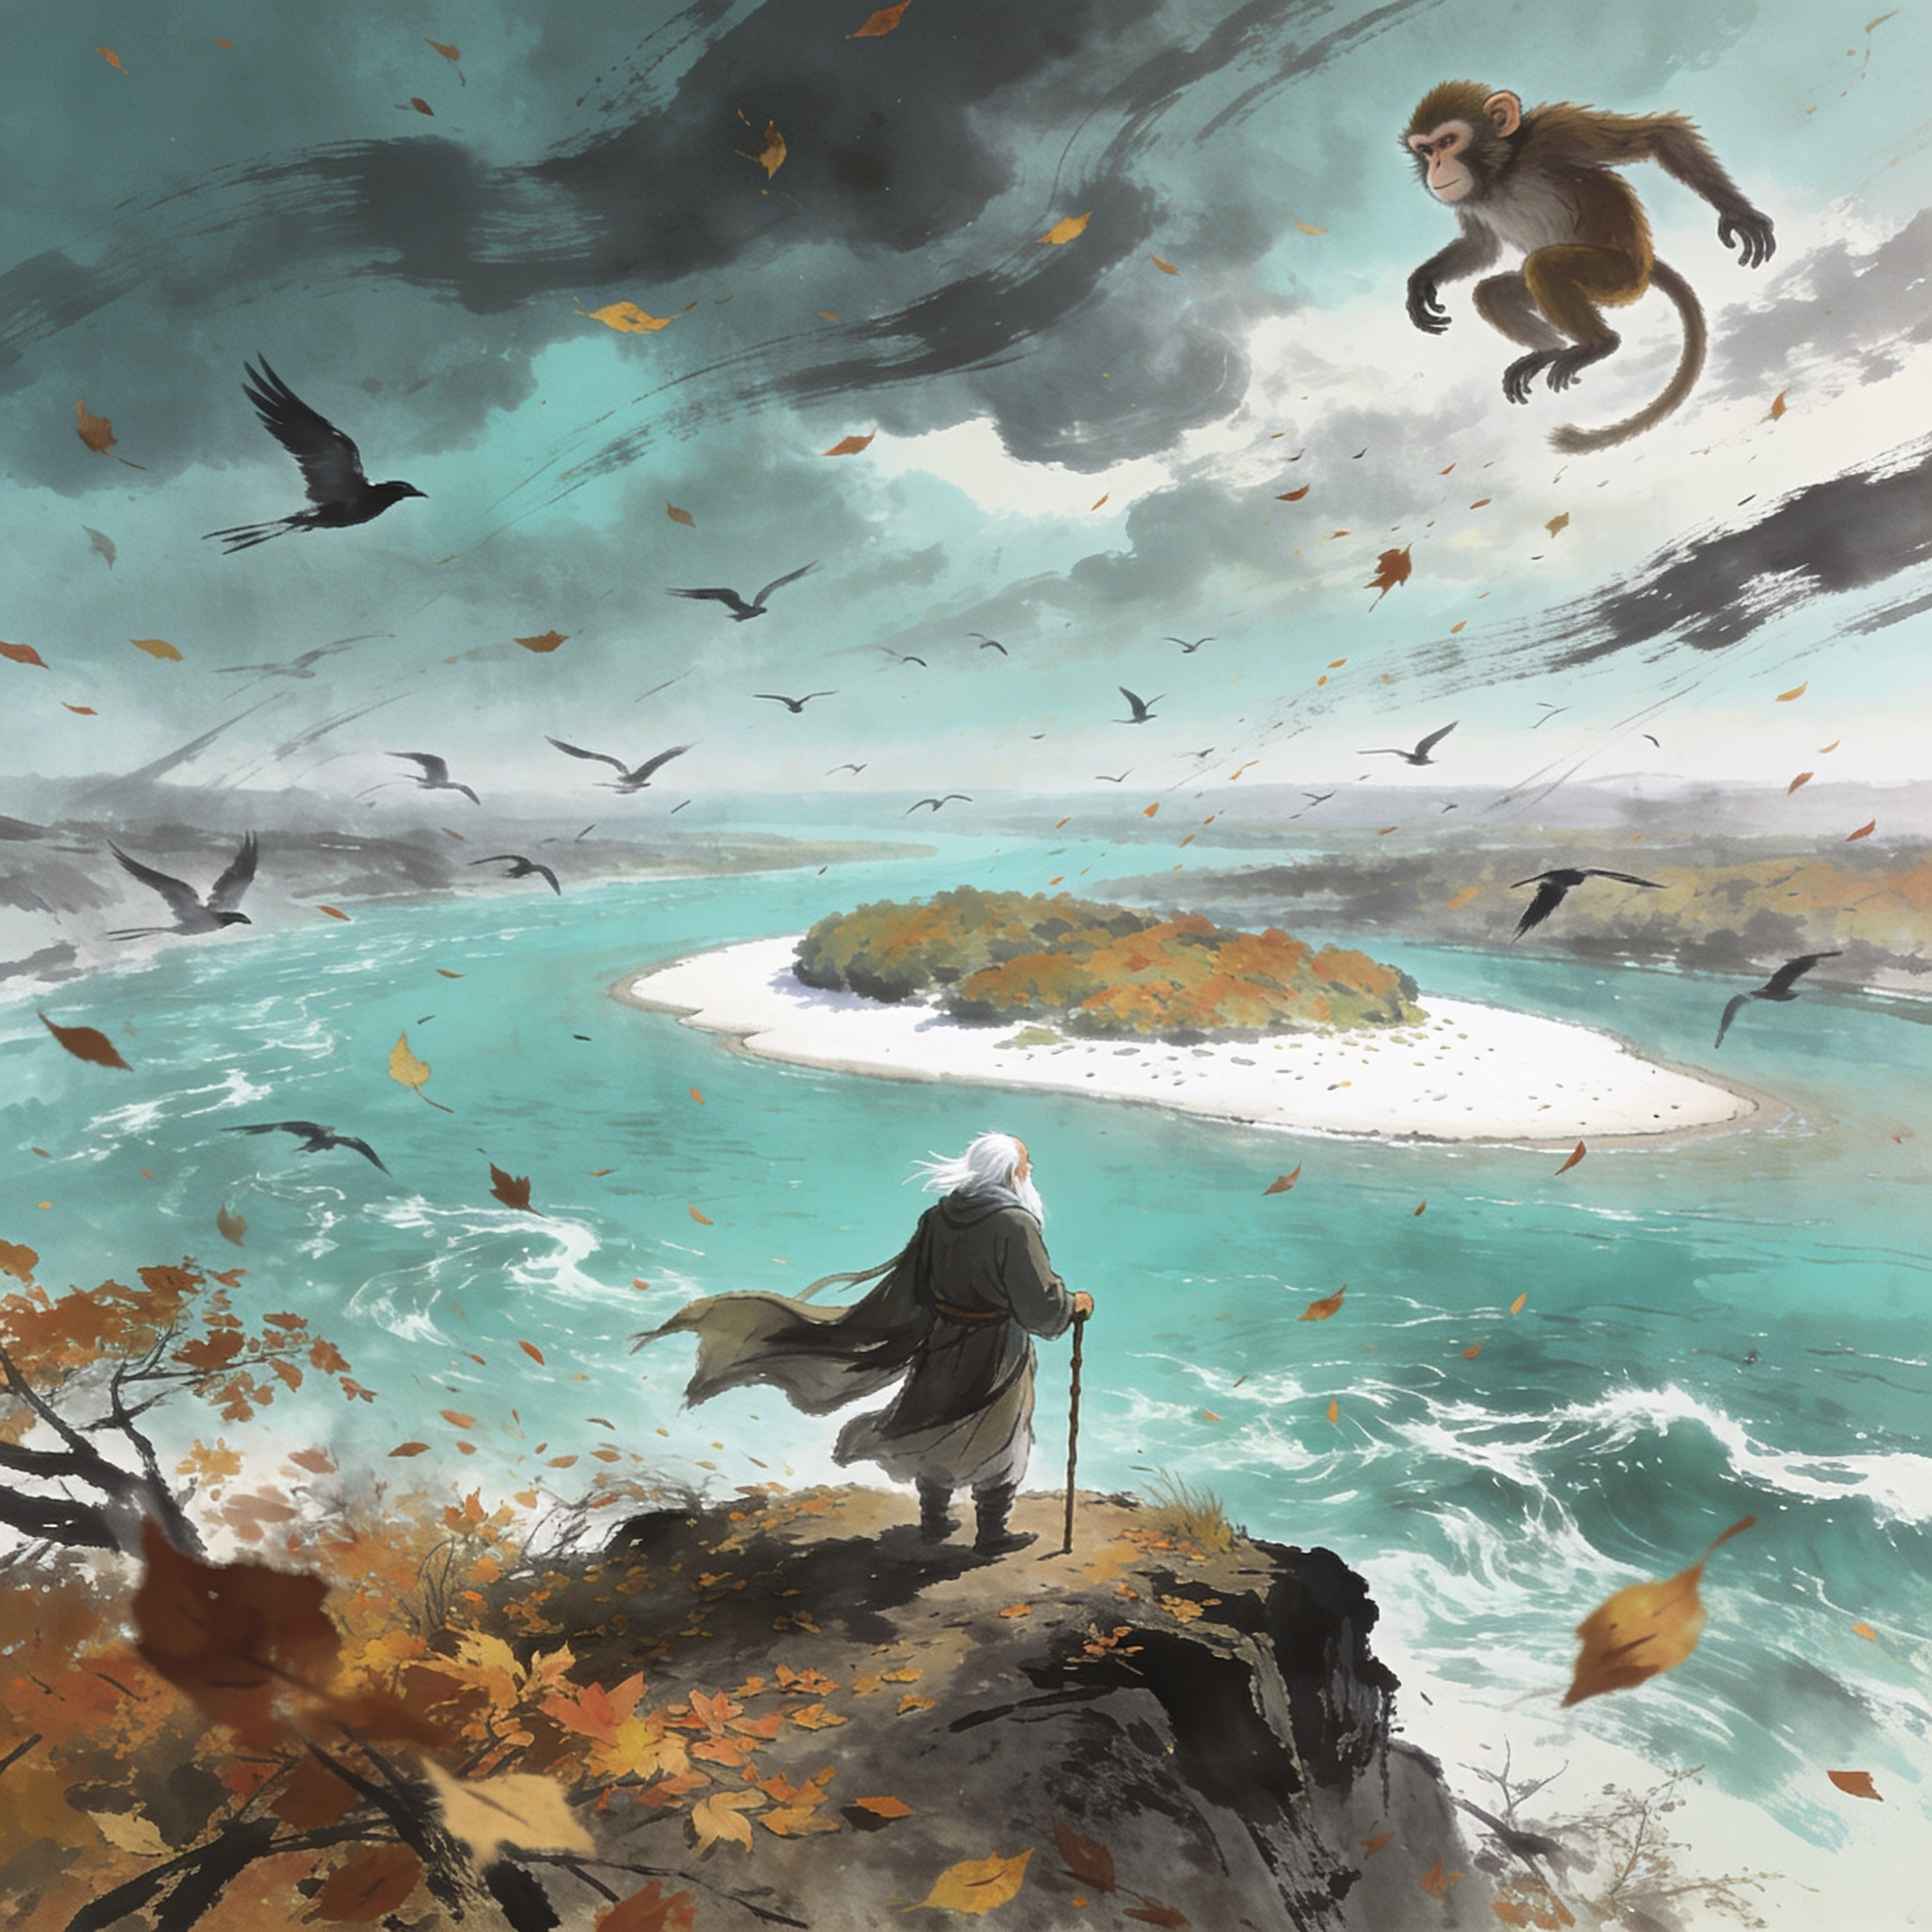

In [13]:
image_path = generate_image(
    prompt=(
            "请根据杜甫的登高创作一个图片"
    ),
    output_path="outputs/denggao.png",
    )

from IPython.display import display, Image
display(Image(filename=str(image_path)))

